In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["Target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'Target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df["Target"].value_counts()

,count
Target,
1,357
0,212


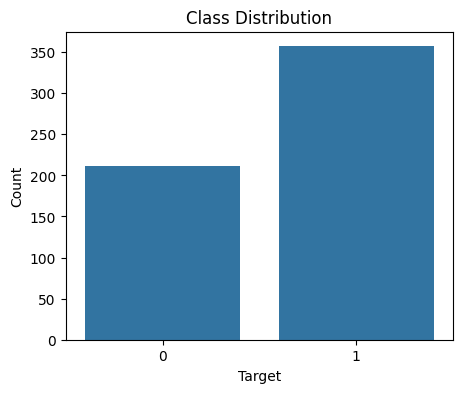

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x="Target", data=df)

plt.title("Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

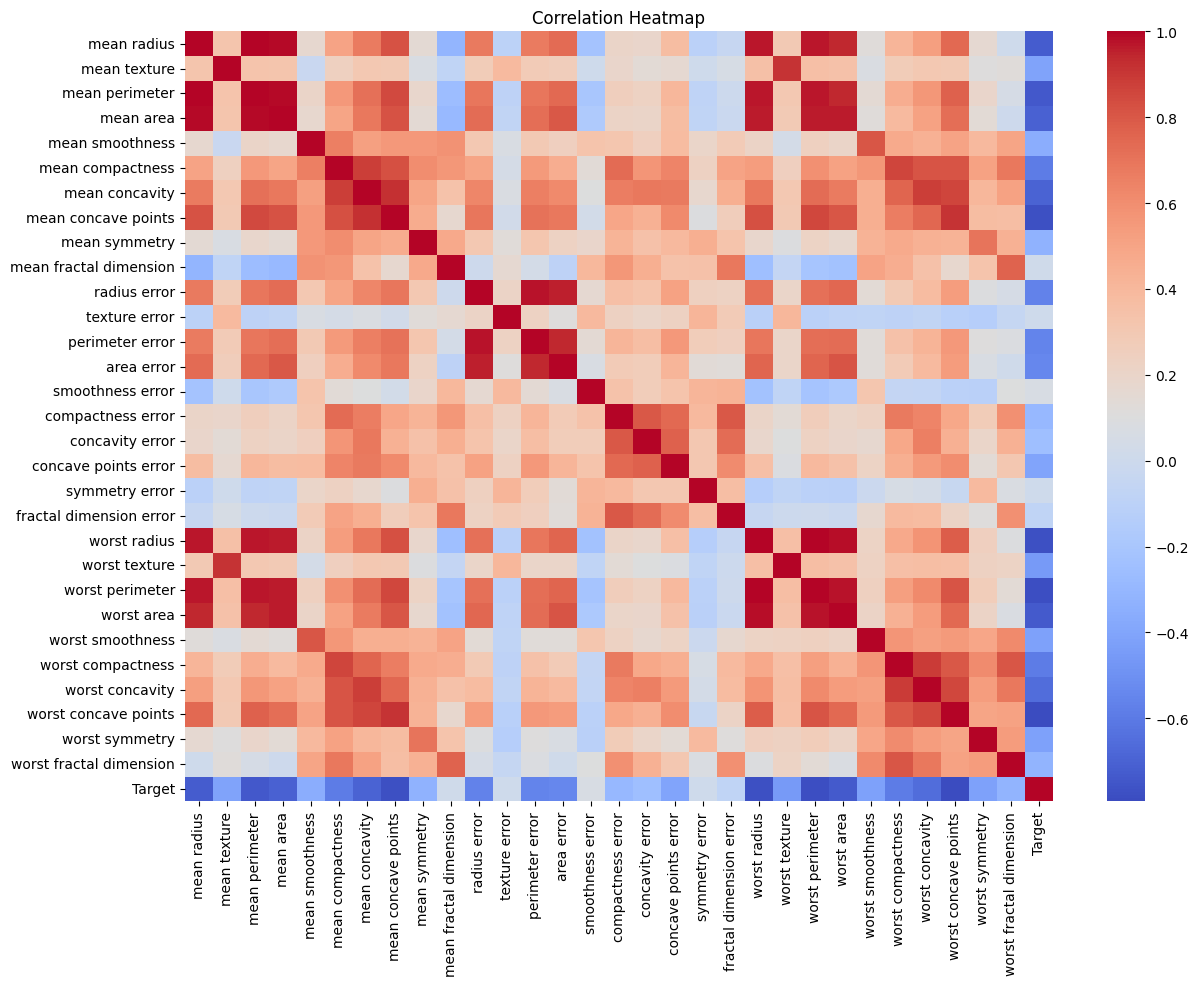

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop("Target", axis=1)

y = df["Target"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (569, 30)
Target Shape : (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (455, 30)
Testing Data : (114, 30)


In [ ]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb.predict(X_test)

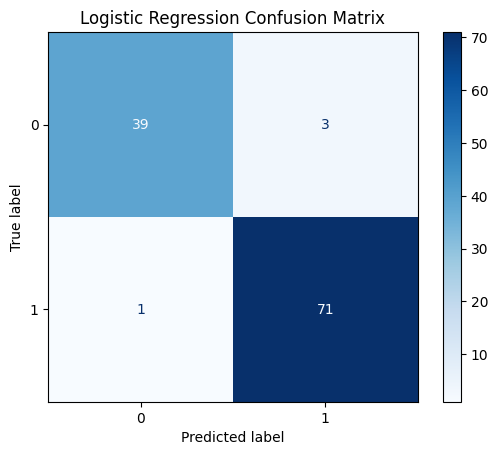

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

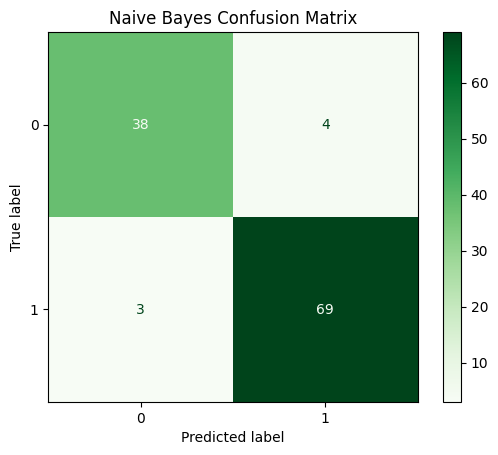

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)

disp.plot(cmap="Greens")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [ ]:
# Logistic Regression Metrics

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Naive Bayes Metrics

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

In [ ]:
print("========== Logistic Regression ==========")
print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

print()

print("========== Naive Bayes ==========")
print("Accuracy :", round(nb_accuracy,4))
print("Precision:", round(nb_precision,4))
print("Recall   :", round(nb_recall,4))
print("F1 Score :", round(nb_f1,4))

========== Logistic Regression ==========
Accuracy : 0.9649
Precision: 0.9595
Recall   : 0.9861
F1 Score : 0.9726

========== Naive Bayes ==========
Accuracy : 0.9386
Precision: 0.9452
Recall   : 0.9583
F1 Score : 0.9517


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall
    ],
    "F1 Score": [
        lr_f1,
        nb_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9649,0.9595,0.9861,0.9726
1,Naive Bayes,0.9386,0.9452,0.9583,0.9517


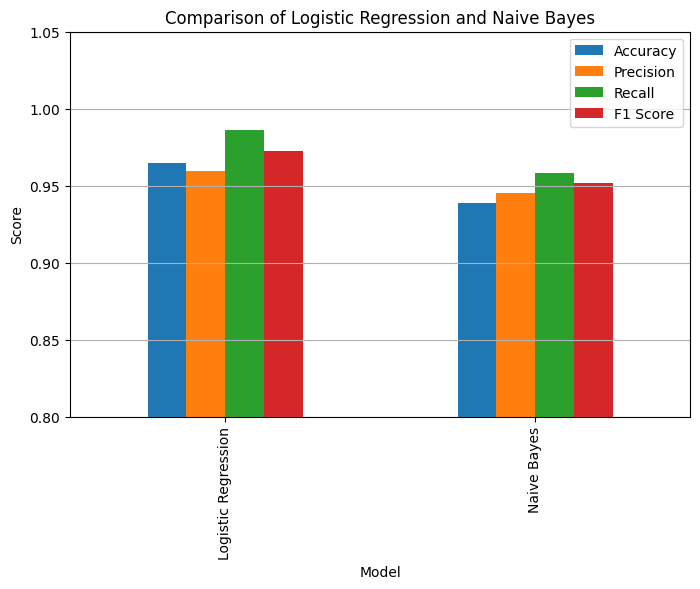

In [ ]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of Logistic Regression and Naive Bayes")
plt.ylabel("Score")
plt.ylim(0.8,1.05)

plt.grid(axis="y")

plt.show()

In [ ]:
print("Logistic Regression Classification Report\n")

print(classification_report(y_test, y_pred_lr))

print("---------------------------------------")

print("Naive Bayes Classification Report\n")

print(classification_report(y_test, y_pred_nb))

Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

---------------------------------------
Naive Bayes Classification Report

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
if lr_accuracy > nb_accuracy:
    print("Best Model : Logistic Regression")
elif nb_accuracy > lr_accuracy:
    print("Best Model : Naive Bayes")
else:
    print("Both models performed equally.")

Best Model : Logistic Regression


In [ ]:
print("""
Conclusion

1. Both Logistic Regression and Naive Bayes were trained on the Breast Cancer dataset.

2. The models were evaluated using Accuracy, Precision, Recall and F1 Score.

3. Their performance was compared using a confusion matrix and evaluation metrics.

4. The model with the higher Accuracy and F1 Score is considered the better classifier for this dataset.

5. Logistic Regression generally performs better when features are correlated, whereas Naive Bayes works well when feature independence approximately holds.
""")


Conclusion

1. Both Logistic Regression and Naive Bayes were trained on the Breast Cancer dataset.

2. The models were evaluated using Accuracy, Precision, Recall and F1 Score.

3. Their performance was compared using a confusion matrix and evaluation metrics.

4. The model with the higher Accuracy and F1 Score is considered the better classifier for this dataset.

5. Logistic Regression generally performs better when features are correlated, whereas Naive Bayes works well when feature independence approximately holds.

